In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [4]:
# Read in all the words in names.txt file.
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [5]:
# Build the vocabulary of characters and mappings to/from integers.
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(f"itos:\n{itos}")
print(f"\nstoi:\n{stoi}")
print("\nVocab size:", vocab_size)

itos:
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}

stoi:
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}

Vocab size: 27


In [6]:
# Shuffle up the words.
import random
random.seed(42)
random.shuffle(words)

In [7]:
# Build the dataset.
block_size = 8        # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
    X, Y = [], []
  
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [8]:
for x,y in zip(Xtr[:22], Ytr[:22]):
    print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e
...xavie --> n
..xavien --> .


In [ ]:
# Near copy paste of the layers we have developed in Part 3

# -----------------------------------------------------------------------------------------------
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5          # note: Kaiming init.
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Embedding:
  
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))
    
  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
  
  def parameters(self):
    return [self.weight]

# -----------------------------------------------------------------------------------------------
class Flatten:

  def __call__(self, x):
    self.out = x.view(x.shape[0], -1)
    return self.out

  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class FlattenConsecutive:
  
  def __init__(self, n):
    # Number of characters to flatten together
    # e.g. if n=2, then (B, T, C) -> (B, T//2, C*2)
    self.n = n
    
  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    # This is for the case where we just want to match the behavior of `Flatten`
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out
  
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Sequential:
  
  def __init__(self, layers):
    self.layers = layers
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out
  
  def parameters(self):
    # get parameters of all layers and stretch them out into one list
    return [p for layer in self.layers for p in layer.parameters()]

In [10]:
# Understanding the view function.
x = torch.randn(2, 3)
print(x.shape)
print(x.view(2, 3, 1).shape)
print(x.view(x.shape[0], -1).shape)

torch.Size([2, 3])
torch.Size([2, 3, 1])
torch.Size([2, 3])


In [11]:
# https://docs.pytorch.org/docs/stable/generated/torch.randint.html
# `size` is a tuple of integers defining the shape of the output tensor.
torch.randint(low=0, high=5, size=(3,))

tensor([2, 4, 2])

In [12]:
torch.manual_seed(42);       # seed for reproducibility.

In [13]:
# Original network.
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 300 # the number of neurons in the hidden layer of the MLP
model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(8), Linear(n_embd * 8, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

32997


In [14]:
# Just getting a sense of the shapes as the inputs pass through the neural network.
batch_size = 32
ix = torch.randint(0, Xtr.shape[0], (batch_size,))
print(ix.shape)

Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
print(Xb.shape, Yb.shape)

e = Embedding(vocab_size, n_embd)
out = e(Xb)
print(out.shape)

flat = out.view(out.shape[0], -1)
print(flat.shape)

torch.Size([32])
torch.Size([32, 8]) torch.Size([32])
torch.Size([32, 8, 10])
torch.Size([32, 80])


In [38]:
l=torch.arange(10).view(2, 5)
l

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [37]:
l.view(l.shape[0], -1)

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [15]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update: simple SGD
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3015
  10000/ 200000: 2.4501
  20000/ 200000: 2.0992
  30000/ 200000: 1.9628
  40000/ 200000: 2.2330
  50000/ 200000: 2.0087
  60000/ 200000: 2.2657
  70000/ 200000: 1.7724
  80000/ 200000: 1.9888
  90000/ 200000: 1.6051
 100000/ 200000: 2.3615
 110000/ 200000: 2.0765
 120000/ 200000: 1.8377
 130000/ 200000: 2.0752
 140000/ 200000: 1.6397
 150000/ 200000: 2.1815
 160000/ 200000: 1.9255
 170000/ 200000: 2.1892
 180000/ 200000: 2.1162
 190000/ 200000: 1.9361


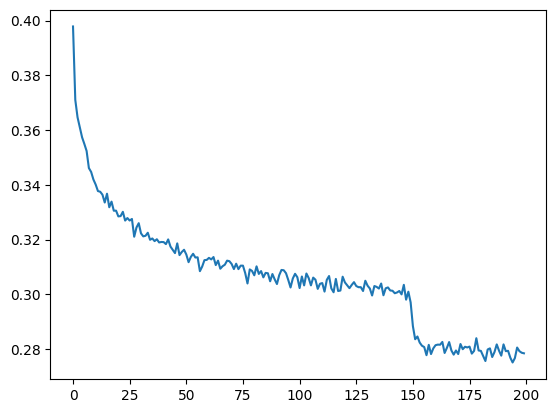

In [16]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [17]:
# Putting the layers in evaluation mode.
for layer in model.layers:
  layer.training = False

In [19]:
# Evaluate the model on the dev set.
@torch.no_grad()
def split_loss(split):
  x, y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte)
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(f'{split} loss:', loss.item())

split_loss('train')
split_loss('val')
split_loss('test')

train loss: 1.8683373928070068
val loss: 2.0112011432647705
test loss: 2.007805347442627


In [20]:
# sample from the model
for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

alaric.
taiclon.
kyrell.
hadilyn.
issael.
elliya.
dayla.
penger.
arian.
ayukemsolro.
achanal.
larama.
juanna.
terand.
jaquya.
tala.
suzeifa.
kataleigh.
shmyah.
castiel.


In [22]:
# Getting a sense of the the shape of the logits as we do the forward pass.
ix = torch.randint(0, Xtr.shape[0], (4,))  # Take a batch of 4.
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
logits = model(Xb)
print(Xb.shape, Yb.shape)
Xb

torch.Size([4, 8]) torch.Size([4])


tensor([[ 0,  0,  0,  0,  0, 11,  1, 25],
        [ 0,  0,  0,  0,  0,  0,  4,  5],
        [ 0,  0,  0,  0, 26,  5,  2, 21],
        [ 0,  0,  0,  0,  0,  0,  2, 15]])

In [23]:
# Embedding layer.
model.layers[0].out.shape

torch.Size([4, 8, 10])

In [24]:
print(model.layers[1].out.shape)    # Flatten
print(model.layers[2].out.shape)    # Linear

torch.Size([4, 80])
torch.Size([4, 300])


In [26]:
# Pytorch treats all the dimensions as a batch dimension. This is because it can do broadcasting.
(torch.randn(4, 5, 6, 80) @ torch.randn(80, 300)).shape

# We want to group the characters such that we only take two characters at a time.
# The above property of pytorch helps here.

torch.Size([4, 5, 6, 300])

In [27]:
# Instead of 8 by 80 we want --> (4, 4, 20) -- Becaause we want to take 2 characters at a time. Each with embedding of 10.
# So we want to group the 8 characters into 4 groups of 2.
# This is what we want:
(torch.randn(4, 4, 20) @ torch.randn(20, 300) + torch.randn(300)).shape

torch.Size([4, 4, 300])

In [39]:
# In python list we can get even and odd indices. Using the same idea here with tensors.
e = torch.randn(4, 8, 10)
print(e[:, ::2, :].shape, e[:, 1::2, :].shape)         # Even and odd slices.

# Concatenate the two slices along the second dimension.
explicit_concat = torch.cat([e[:, ::2, :], e[:, 1::2, :]], dim=2)
explicit_concat.shape

torch.Size([4, 4, 10]) torch.Size([4, 4, 10])


torch.Size([4, 4, 20])

In [40]:
# Easier way is to use the view function.
e.view(4, 4, 20).shape

torch.Size([4, 4, 20])

In [ ]:
(explicit_concat == e.view(4, 4, 20)).all() # Check if they are equal.

# Using this idea we write the FlattenConsecutive layer.

tensor(True)

In [ ]:
# Try with a small example.
# 2 batches, 8 characters, 2 embedding size.
e = torch.randn(2, 8, 2)
e

tensor([[[ 1.1837,  2.4529],
         [-0.4038,  0.8932],
         [ 0.2505, -0.0839],
         [ 2.1616, -1.1669],
         [-0.7413, -2.6241],
         [ 1.0097,  0.1648],
         [ 0.6312, -1.1305],
         [-0.4333,  1.9066]],

        [[ 0.9414,  1.7498],
         [ 0.2084, -0.3623],
         [-1.0111, -0.0345],
         [ 0.6924, -1.3413],
         [-0.1229,  0.2823],
         [ 2.1144, -0.3739],
         [-0.5713, -0.0718],
         [-0.3335, -1.4985]]])

In [50]:
print(e[:, ::2, :])
print()
print(e[:, 1::2, :])
print(e[:, ::2, :].shape, e[:, 1::2, :].shape)

tensor([[[ 1.1837,  2.4529],
         [ 0.2505, -0.0839],
         [-0.7413, -2.6241],
         [ 0.6312, -1.1305]],

        [[ 0.9414,  1.7498],
         [-1.0111, -0.0345],
         [-0.1229,  0.2823],
         [-0.5713, -0.0718]]])

tensor([[[-0.4038,  0.8932],
         [ 2.1616, -1.1669],
         [ 1.0097,  0.1648],
         [-0.4333,  1.9066]],

        [[ 0.2084, -0.3623],
         [ 0.6924, -1.3413],
         [ 2.1144, -0.3739],
         [-0.3335, -1.4985]]])
torch.Size([2, 4, 2]) torch.Size([2, 4, 2])


In [52]:
explicit_concat = torch.cat([e[:, ::2, :], e[:, 1::2, :]], dim=2)
print(explicit_concat)
print(explicit_concat.shape)
# This shows that we get embeddings of 2 characters concatenated together.

tensor([[[ 1.1837,  2.4529, -0.4038,  0.8932],
         [ 0.2505, -0.0839,  2.1616, -1.1669],
         [-0.7413, -2.6241,  1.0097,  0.1648],
         [ 0.6312, -1.1305, -0.4333,  1.9066]],

        [[ 0.9414,  1.7498,  0.2084, -0.3623],
         [-1.0111, -0.0345,  0.6924, -1.3413],
         [-0.1229,  0.2823,  2.1144, -0.3739],
         [-0.5713, -0.0718, -0.3335, -1.4985]]])
torch.Size([2, 4, 4])


In [ ]:
# This will be identical to the explicit concatenation above.
e.view(2, 4, 4)

# Now go and check the FlattenConsecutive layer.

tensor([[[ 1.1837,  2.4529, -0.4038,  0.8932],
         [ 0.2505, -0.0839,  2.1616, -1.1669],
         [-0.7413, -2.6241,  1.0097,  0.1648],
         [ 0.6312, -1.1305, -0.4333,  1.9066]],

        [[ 0.9414,  1.7498,  0.2084, -0.3623],
         [-1.0111, -0.0345,  0.6924, -1.3413],
         [-0.1229,  0.2823,  2.1144, -0.3739],
         [-0.5713, -0.0718, -0.3335, -1.4985]]])

In [61]:
# In the block earlier we used FllattenConsecutive(8) to flatten the embedding. That was just a normal flatten.
# Now let's try to flatten the embedding with 2 characters at a time as being done in with randn above.

# Also add more layers to the model (compare with the original network from earlier.

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 300 # the number of neurons in the hidden layer of the MLP
consecutive_chars = 2 # number of characters to flatten together
model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(consecutive_chars), Linear(n_embd * consecutive_chars,
                                                n_hidden,
                                                bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(consecutive_chars), Linear(n_hidden * consecutive_chars,
                                                n_hidden,
                                                bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(consecutive_chars), Linear(n_hidden * consecutive_chars,
                                                n_hidden,
                                                bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

376197


In [54]:
# Understand linear layer.
lin = Linear(4, 3)
x = torch.randn(2, 4)
x = lin(x)
print(x.shape)

torch.Size([2, 3])


In [ ]:
# Trying to emulate our model.
lin = Linear(20, 300)
# Batch-size of 2 and 8 chars but 2 chars at a time so we get the embedding size of 20.
x = torch.randn(2, 4, 20)
x = lin(x)
print(x.shape)

torch.Size([2, 4, 300])


In [56]:
fl = FlattenConsecutive(2)
x = fl(x)
print(x.shape)

torch.Size([2, 2, 600])


In [57]:
lin2 = Linear(600, 300)
x = lin2(x)
print(x.shape)

torch.Size([2, 2, 300])


In [58]:
x = fl(x)
print(x.shape)

torch.Size([2, 600])


In [ ]:
x = lin2(x)
print(x.shape)

# This completes the model flow and we see the right shapes. Finally after this we map to the vocab size.
# We will get 2*voca_size logits. Because we have 2 batches. That's the prediction for the next character (9th char).

torch.Size([2, 300])


In [66]:
# Now let's inspect the shapes of the model we have above by doing a single forward pass.
ix = torch.randint(0, Xtr.shape[0], (4,))  # Take a batch of 4.
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
logits = model(Xb)
print(Xb.shape, Yb.shape)
Xb

torch.Size([4, 8]) torch.Size([4])


tensor([[ 0,  0,  0, 19,  1,  8,  9, 18],
        [ 0,  0,  0, 11, 25,  1,  9, 18],
        [ 0,  8, 21, 14, 20, 12,  5,  9],
        [ 0,  0,  0,  0, 20,  8,  5,  1]])

In [67]:
for layer in model.layers:
  print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 300)
BatchNorm1d : (4, 4, 300)
Tanh : (4, 4, 300)
FlattenConsecutive : (4, 2, 600)
Linear : (4, 2, 300)
BatchNorm1d : (4, 2, 300)
Tanh : (4, 2, 300)
FlattenConsecutive : (4, 600)
Linear : (4, 300)
BatchNorm1d : (4, 300)
Tanh : (4, 300)
Linear : (4, 27)


In [68]:
logits.shape

torch.Size([4, 27])

In [69]:
# Let's run the training with the new model.
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update: simple SGD
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.2710
  10000/ 200000: 2.2385
  20000/ 200000: 2.3561
  30000/ 200000: 2.2935
  40000/ 200000: 2.0930
  50000/ 200000: 1.5791
  60000/ 200000: 1.7299
  70000/ 200000: 2.0558
  80000/ 200000: 2.2506
  90000/ 200000: 2.1577
 100000/ 200000: 2.1273
 110000/ 200000: 2.2290
 120000/ 200000: 2.3748
 130000/ 200000: 2.3591
 140000/ 200000: 2.1634
 150000/ 200000: 1.3170
 160000/ 200000: 1.7125
 170000/ 200000: 1.4690
 180000/ 200000: 2.0727
 190000/ 200000: 1.7907


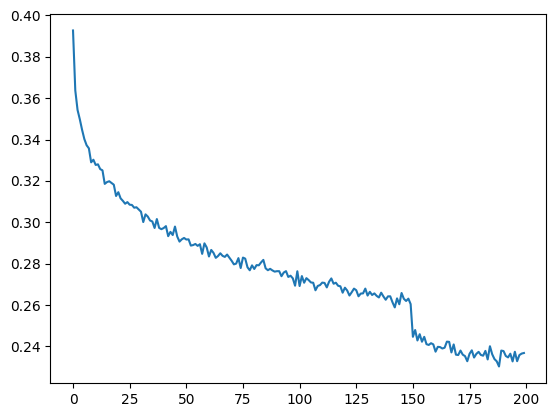

In [70]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [71]:
# Putting the layers in evaluation mode.
for layer in model.layers:
  layer.training = False

# Evaluate the model on the dev set.
@torch.no_grad()
def split_loss(split):
  x, y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte)
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(f'{split} loss:', loss.item())

split_loss('train')
split_loss('val')
split_loss('test')

train loss: 1.694191336631775
val loss: 1.9974781274795532
test loss: 1.9888427257537842


In [72]:
# sample from the model
for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

maxime.
klaine.
zaairha.
caylana.
athalynn.
ayat.
muslyn.
cornella.
jaslynn.
maish.
kailan.
gwyn.
malan.
leonelli.
lilty.
wilbert.
davyn.
zakari.
daysie.
clayten.
